# Platform network-adaptation probability probe

- **Submodel ID:** SM-PLAT-NET-ADAPT-PROB-01
- **Case:** `platform`
- **Status:** bounded implementation probe; not calibration or empirical validation
- **Round horizon:** 10


## Question and interpretation

This notebook asks how tying and untying behave over ten rounds when the out-of-network availability probability is low, middle, or high. It keeps ordinary origination, homogeneous aggregation, Beta updating, processing capacity, initial beliefs, and the initial sparse network fixed.

The platform parameter $\rho$ changes whether untied messages become candidates for attention. It is not an input to the conditional network-decision equations. Therefore the probe separates:

1. **assigned decision probability**, $p_{ij,+}^t$ or $p_{ij,-}^t$, conditional on a retained exposure creating an opportunity; and
2. **agent event probability**, the Monte Carlo probability that an agent forms or dissolves at least one tie in a round.

The second quantity incorporates both opportunity generation and the Bernoulli network decision, so it is the primary comparison across $\rho$ scenarios.


## Implemented decision equations

For $N$ agents, define normalized and centered following degree

$$d_i^t=\frac{k_i^t}{N-1}, \qquad z_i^t=2d_i^t-1.$$

With Beta-tail alignment $a_{ij}^t=x_j^t(2q_i^t-1)$, the implemented probabilities are

$$p_{ij,+}^t=\sigma\left(\operatorname{logit}(\pi_+)-\beta_{+,k}z_i^t+\beta_{+,a}a_{ij}^t\right),$$

$$p_{ij,-}^t=\sigma\left(\operatorname{logit}(\pi_-)+\beta_{-,k}z_i^t-\beta_{-,a}a_{ij}^t\right).$$

The parameter values below are illustrative probe settings, not estimates.


In [1]:
from __future__ import annotations

import sys
from dataclasses import replace
from math import log
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src' / 'opinion_model').exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from opinion_model.baseline import (
    BASELINE_COMPONENTS,
    SimulationConfig,
    initialize_baseline,
    run_simulation,
)
from opinion_model.core import NetworkState, WorldState
from opinion_model.platform import (
    PlatformMessageSelection,
    PlatformNetworkUpdate,
    network_decision_frame,
    tie_dissolution_probability,
    tie_formation_probability,
)

sns.set_theme(style='whitegrid', context='notebook')

RHO_SCENARIOS = {
    'low': 0.1,
    'middle': 0.5,
    'high': 0.9,
}
ROUNDS = 10
AGENT_COUNT = 30
INITIAL_FOLLOWING_DEGREE = 4
CAPACITY = 10
REPLICATIONS = 200
BASE_SEED = 20260909

MIDPOINT_FORMATION = 0.10
MIDPOINT_DISSOLUTION = 0.10
DEGREE_STRENGTH = log(3.0)
ALIGNMENT_STRENGTH = log(3.0)

BASE_CONFIG = SimulationConfig(
    agent_count=AGENT_COUNT,
    rounds=ROUNDS,
    seed=BASE_SEED,
    initial_mean=0.5,
    initial_concentration=4.0,
    base_origination_probability=1.0,
    evidence_weight=0.1,
    consumption_capacity=CAPACITY,
    exclude_self_messages=True,
)

pd.Series({
    'rounds': ROUNDS,
    'agents': AGENT_COUNT,
    'initial following degree': INITIAL_FOLLOWING_DEGREE,
    'capacity': CAPACITY,
    'replications per scenario': REPLICATIONS,
    **{f'rho ({name})': value for name, value in RHO_SCENARIOS.items()},
}, name='probe configuration')


rounds                        10.0
agents                        30.0
initial following degree       4.0
capacity                      10.0
replications per scenario    200.0
rho (low)                      0.1
rho (middle)                   0.5
rho (high)                     0.9
Name: probe configuration, dtype: float64

## Structural probability checks

Before running the stochastic scenarios, evaluate the implemented equations directly. Formation should fall with degree and rise with alignment; dissolution should rise with degree and fall with alignment.


In [2]:
ALIGNMENTS = np.linspace(-1.0, 1.0, 101)
DEGREE_LEVELS = {
    'low degree': round(0.1 * (AGENT_COUNT - 1)),
    'middle degree': round(0.5 * (AGENT_COUNT - 1)),
    'high degree': round(0.9 * (AGENT_COUNT - 1)),
}

probability_rows = []
for degree_label, following_degree in DEGREE_LEVELS.items():
    for alignment in ALIGNMENTS:
        common = {
            'following_degree': following_degree,
            'agent_count': AGENT_COUNT,
            'alignment': alignment,
            'degree_log_odds_strength': DEGREE_STRENGTH,
            'alignment_log_odds_strength': ALIGNMENT_STRENGTH,
        }
        probability_rows.extend([
            {
                'action': 'tie',
                'degree_label': degree_label,
                'following_degree': following_degree,
                'alignment': alignment,
                'probability': tie_formation_probability(
                    midpoint_probability=MIDPOINT_FORMATION,
                    **common,
                ),
            },
            {
                'action': 'untie',
                'degree_label': degree_label,
                'following_degree': following_degree,
                'alignment': alignment,
                'probability': tie_dissolution_probability(
                    midpoint_probability=MIDPOINT_DISSOLUTION,
                    **common,
                ),
            },
        ])

probability_grid = pd.DataFrame(probability_rows)
assert probability_grid['probability'].between(0.0, 1.0, inclusive='neither').all()

for _, group in probability_grid.groupby(['action', 'degree_label']):
    values = group.sort_values('alignment')['probability'].to_numpy()
    if group['action'].iat[0] == 'tie':
        assert np.all(np.diff(values) > 0.0)
    else:
        assert np.all(np.diff(values) < 0.0)

for action, group in probability_grid.groupby('action'):
    at_neutral = group[np.isclose(group['alignment'], 0.0)]
    ordered = at_neutral.set_index('degree_label').loc[list(DEGREE_LEVELS)]
    differences = np.diff(ordered['probability'])
    assert np.all(differences < 0.0) if action == 'tie' else np.all(differences > 0.0)

print(f'All structural checks passed for {len(probability_grid):,} evaluations.')


All structural checks passed for 606 evaluations.


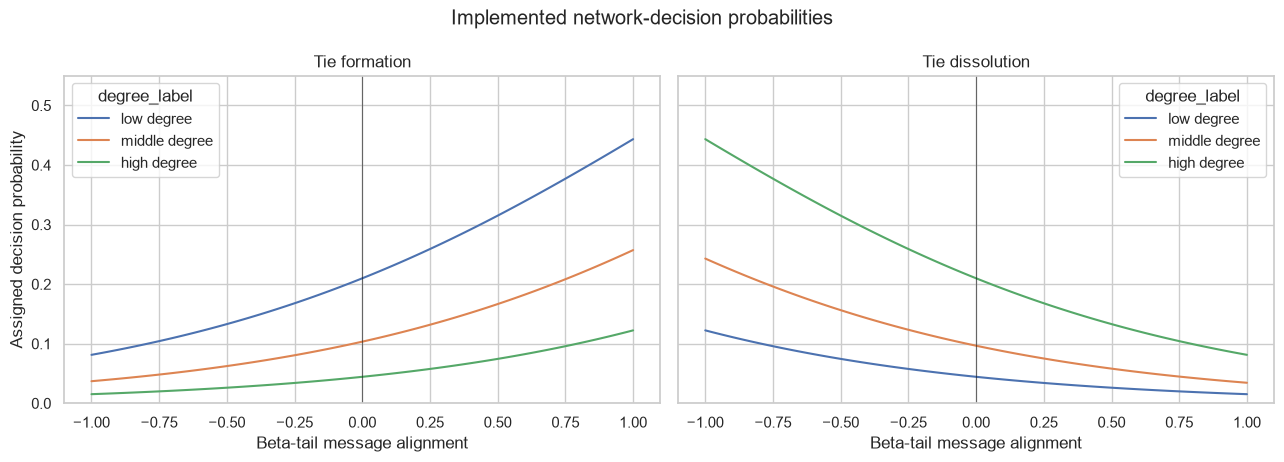

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), sharey=True)
for axis, action, title in zip(
    axes,
    ('tie', 'untie'),
    ('Tie formation', 'Tie dissolution'),
):
    subset = probability_grid.query('action == @action')
    sns.lineplot(
        data=subset,
        x='alignment',
        y='probability',
        hue='degree_label',
        hue_order=list(DEGREE_LEVELS),
        ax=axis,
    )
    axis.axvline(0.0, color='black', linewidth=0.8, alpha=0.5)
    axis.set_title(title)
    axis.set_xlabel('Beta-tail message alignment')
    axis.set_ylim(0.0, 0.55)
axes[0].set_ylabel('Assigned decision probability')
axes[1].set_ylabel('')
fig.suptitle('Implemented network-decision probabilities')
fig.tight_layout()


## Ten-round matched-scenario probe

The complete baseline network cannot exhibit out-of-network reach. This bounded probe therefore uses a deterministic sparse directed ring: every agent initially follows the next four agents. This is a transparent diagnostic fixture, not a proposed empirical initialization model.

Each replication seed is reused across all three $\rho$ values. Probabilities and uncertainty intervals are summarized across replications rather than treating every agent observation as an independent replication.


In [4]:
def initialize_sparse_ring(config: SimulationConfig, rng) -> WorldState:
    baseline = initialize_baseline(config, rng)
    neighbors = {
        consumer_id: tuple(
            (consumer_id + offset) % config.agent_count
            for offset in range(1, INITIAL_FOLLOWING_DEGREE + 1)
        )
        for consumer_id in baseline.agents
    }
    return WorldState(
        round_index=0,
        agents=baseline.agents,
        network=NetworkState(neighbors),
    )


def make_network_rule() -> PlatformNetworkUpdate:
    return PlatformNetworkUpdate(
        formation_midpoint_probability=MIDPOINT_FORMATION,
        formation_degree_log_odds_strength=DEGREE_STRENGTH,
        formation_alignment_log_odds_strength=ALIGNMENT_STRENGTH,
        dissolution_midpoint_probability=MIDPOINT_DISSOLUTION,
        dissolution_degree_log_odds_strength=DEGREE_STRENGTH,
        dissolution_alignment_log_odds_strength=ALIGNMENT_STRENGTH,
    )


def make_components(rho: float, network_rule: PlatformNetworkUpdate):
    return replace(
        BASELINE_COMPONENTS,
        initializer=initialize_sparse_ring,
        message_selection=PlatformMessageSelection(rho),
        network_update=network_rule,
    )


In [5]:
agent_event_rows = []
decision_summary_rows = []
degree_rows = []

for scenario, rho in RHO_SCENARIOS.items():
    for replication in range(REPLICATIONS):
        config = replace(BASE_CONFIG, seed=BASE_SEED + replication)
        network_rule = make_network_rule()
        result = run_simulation(config, make_components(rho, network_rule))
        decisions = network_decision_frame(result, network_rule)

        for round_result in result.rounds:
            round_index = round_result.next_state.round_index
            round_decisions = decisions.query('round == @round_index')

            for action in ('tie', 'untie'):
                action_decisions = round_decisions.query('action == @action')
                opportunity_count = len(action_decisions)
                decision_summary_rows.append({
                    'scenario': scenario,
                    'rho': rho,
                    'replication': replication,
                    'round': round_index,
                    'action': action,
                    'opportunities_per_agent': opportunity_count / AGENT_COUNT,
                    'conditional_assigned_probability': (
                        action_decisions['probability'].mean()
                        if opportunity_count else np.nan
                    ),
                    'realized_acceptance_rate': (
                        action_decisions['accepted'].mean()
                        if opportunity_count else np.nan
                    ),
                })

                accepted_consumers = set(
                    action_decisions.loc[
                        action_decisions['accepted'], 'consumer_id'
                    ]
                )
                consumers_with_opportunity = set(action_decisions['consumer_id'])
                for consumer_id in range(AGENT_COUNT):
                    agent_event_rows.append({
                        'scenario': scenario,
                        'rho': rho,
                        'replication': replication,
                        'round': round_index,
                        'consumer_id': consumer_id,
                        'action': action,
                        'had_opportunity': consumer_id in consumers_with_opportunity,
                        'had_event': consumer_id in accepted_consumers,
                    })

            snapshot = round_result.snapshot
            degree_rows.append({
                'scenario': scenario,
                'rho': rho,
                'replication': replication,
                'round': round_index,
                'mean_start_degree': np.mean([
                    len(snapshot.network.eligible_producers(agent_id))
                    for agent_id in snapshot.agents
                ]),
            })

agent_events = pd.DataFrame(agent_event_rows)
decision_runs = pd.DataFrame(decision_summary_rows)
degree_runs = pd.DataFrame(degree_rows)

assert len(agent_events) == len(RHO_SCENARIOS) * REPLICATIONS * ROUNDS * AGENT_COUNT * 2
assert agent_events['round'].between(1, ROUNDS).all()
assert set(agent_events['scenario']) == set(RHO_SCENARIOS)
assert decision_runs['conditional_assigned_probability'].dropna().between(0.0, 1.0).all()
assert decision_runs['realized_acceptance_rate'].dropna().between(0.0, 1.0).all()

print(f'Completed {len(RHO_SCENARIOS) * REPLICATIONS:,} matched simulations.')
print(f'Recorded {len(agent_events):,} agent-round-action observations.')


Completed 600 matched simulations.
Recorded 360,000 agent-round-action observations.


## Agent-level tying and untying probabilities

For each replication and round, first calculate the fraction of agents with at least one accepted tie or untie decision. The curves show the mean of those replication-level fractions. Bands are normal-approximation 95% intervals across the matched replications.


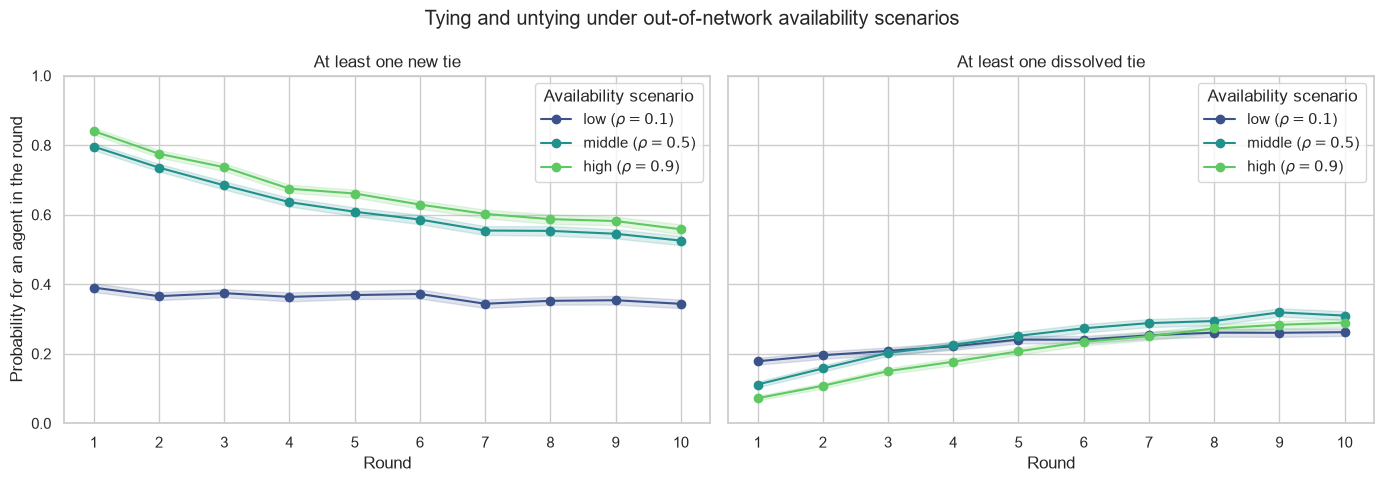

In [6]:
event_runs = (
    agent_events
    .groupby(['scenario', 'rho', 'replication', 'round', 'action'], as_index=False)
    .agg(event_probability=('had_event', 'mean'))
)
event_summary = (
    event_runs
    .groupby(['scenario', 'rho', 'round', 'action'], as_index=False)
    .agg(
        probability=('event_probability', 'mean'),
        standard_error=('event_probability', 'sem'),
    )
)
event_summary['lower'] = (
    event_summary['probability'] - 1.96 * event_summary['standard_error']
).clip(lower=0.0)
event_summary['upper'] = (
    event_summary['probability'] + 1.96 * event_summary['standard_error']
).clip(upper=1.0)

colors = dict(zip(RHO_SCENARIOS, sns.color_palette('viridis', 3)))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), sharey=True)
for axis, action, title in zip(
    axes,
    ('tie', 'untie'),
    ('At least one new tie', 'At least one dissolved tie'),
):
    for scenario in RHO_SCENARIOS:
        subset = event_summary.query(
            'action == @action and scenario == @scenario'
        ).sort_values('round')
        axis.plot(
            subset['round'],
            subset['probability'],
            marker='o',
            label=fr"{scenario} ($\rho={RHO_SCENARIOS[scenario]:.1f}$)",
            color=colors[scenario],
        )
        axis.fill_between(
            subset['round'],
            subset['lower'],
            subset['upper'],
            color=colors[scenario],
            alpha=0.16,
        )
    axis.set_title(title)
    axis.set_xlabel('Round')
    axis.set_xticks(range(1, ROUNDS + 1))
    axis.set_ylim(0.0, 1.0)
axes[0].set_ylabel('Probability for an agent in the round')
axes[1].set_ylabel('')
axes[0].legend(title='Availability scenario')
axes[1].legend(title='Availability scenario')
fig.suptitle('Tying and untying under out-of-network availability scenarios')
fig.tight_layout()


## Why the event probabilities change

The next panels separate opportunity supply from the conditional probability assigned once an opportunity exists. The final panel shows the evolving start-of-round following degree.


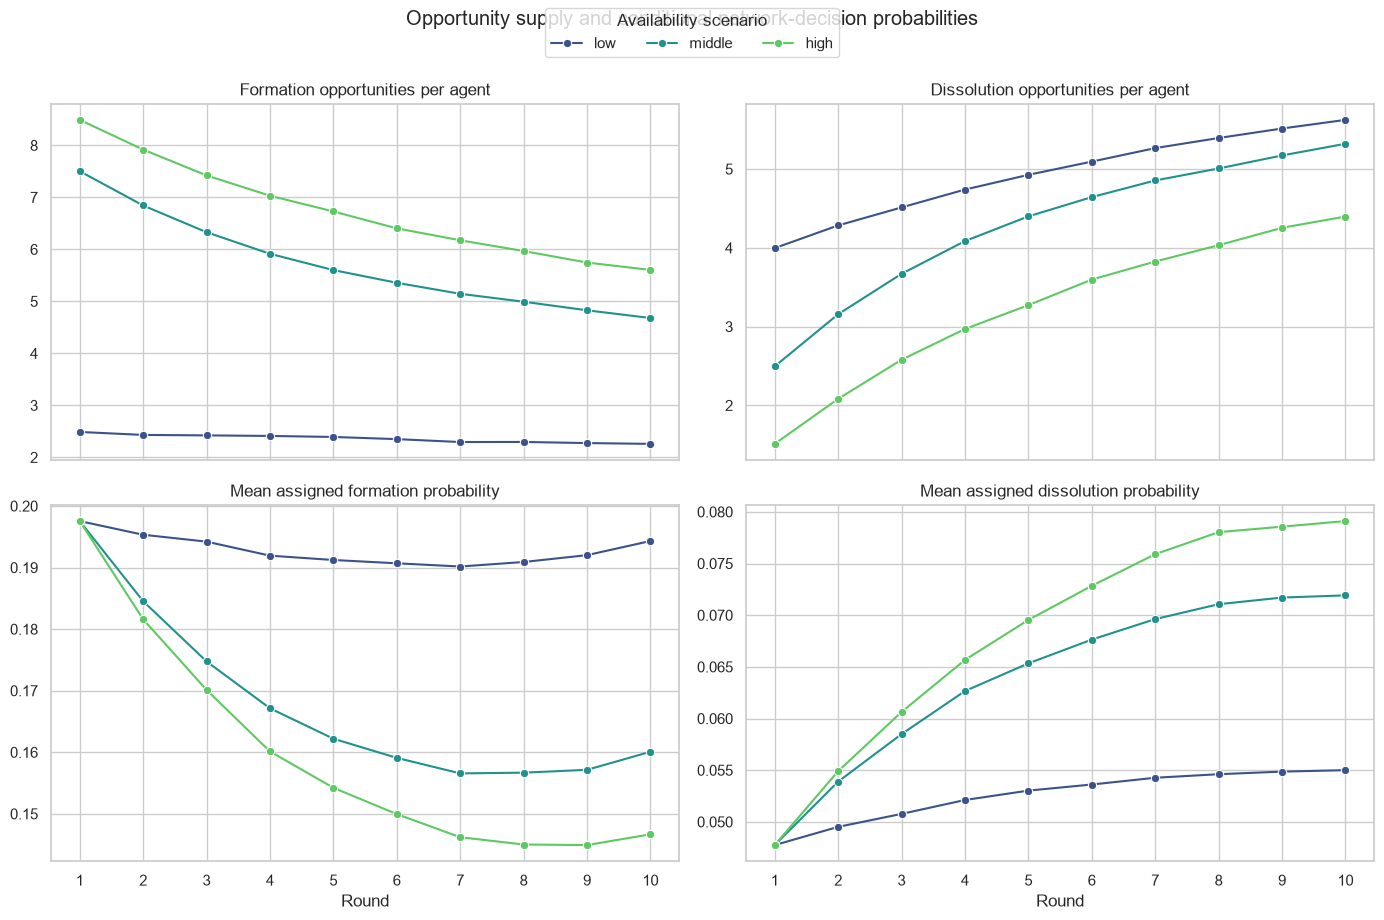

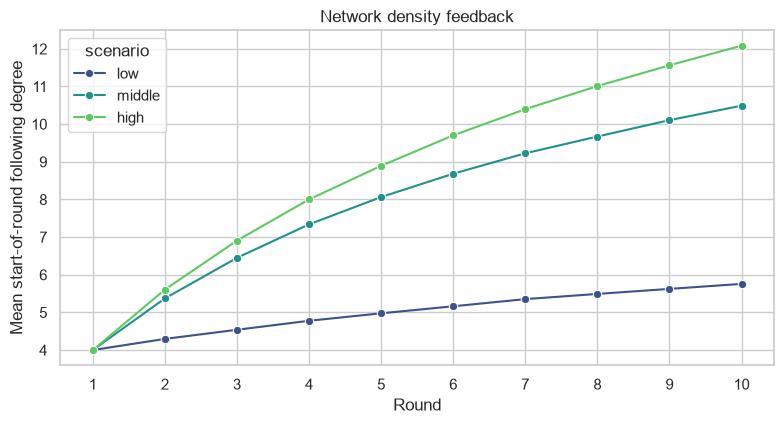

In [7]:
decision_summary = (
    decision_runs
    .groupby(['scenario', 'rho', 'round', 'action'], as_index=False)
    .agg(
        opportunities_per_agent=('opportunities_per_agent', 'mean'),
        conditional_assigned_probability=('conditional_assigned_probability', 'mean'),
        realized_acceptance_rate=('realized_acceptance_rate', 'mean'),
    )
)
degree_summary = (
    degree_runs
    .groupby(['scenario', 'rho', 'round'], as_index=False)
    .agg(mean_start_degree=('mean_start_degree', 'mean'))
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
panels = [
    ('tie', 'opportunities_per_agent', 'Formation opportunities per agent'),
    ('untie', 'opportunities_per_agent', 'Dissolution opportunities per agent'),
    ('tie', 'conditional_assigned_probability', 'Mean assigned formation probability'),
    ('untie', 'conditional_assigned_probability', 'Mean assigned dissolution probability'),
]
for axis, (action, measure, title) in zip(axes.flat, panels):
    subset = decision_summary.query('action == @action')
    sns.lineplot(
        data=subset,
        x='round',
        y=measure,
        hue='scenario',
        hue_order=list(RHO_SCENARIOS),
        palette=colors,
        marker='o',
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel('Round')
    axis.set_xticks(range(1, ROUNDS + 1))
    axis.set_ylabel('')
    axis.legend_.remove()
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, title='Availability scenario')
fig.suptitle('Opportunity supply and conditional network-decision probabilities', y=1.02)
fig.tight_layout()

plt.figure(figsize=(8, 4.4))
sns.lineplot(
    data=degree_summary,
    x='round',
    y='mean_start_degree',
    hue='scenario',
    hue_order=list(RHO_SCENARIOS),
    palette=colors,
    marker='o',
)
plt.xticks(range(1, ROUNDS + 1))
plt.xlabel('Round')
plt.ylabel('Mean start-of-round following degree')
plt.title('Network density feedback')
plt.tight_layout()


## Selected numerical results

The table reports rounds 1, 5, and 10. Event probability is the primary outcome; conditional assigned probability describes the decision rule only after an opportunity exists.


In [8]:
selected = (
    event_summary
    .query('round in [1, 5, 10]')
    .merge(
        decision_summary,
        on=['scenario', 'rho', 'round', 'action'],
        how='left',
    )
    .merge(degree_summary, on=['scenario', 'rho', 'round'], how='left')
    [[
        'scenario',
        'rho',
        'round',
        'action',
        'probability',
        'lower',
        'upper',
        'opportunities_per_agent',
        'conditional_assigned_probability',
        'realized_acceptance_rate',
        'mean_start_degree',
    ]]
    .sort_values(['action', 'round', 'rho'])
)
selected.round(4)


,scenario,rho,round,action,probability,lower,upper,opportunities_per_agent,conditional_assigned_probability,realized_acceptance_rate,mean_start_degree
6,low,0.1,1,tie,0.3903,0.3777,0.4030,2.4878,0.1976,0.1952,4.0000
12,middle,0.5,1,tie,0.7960,0.7859,0.8061,7.5022,0.1976,0.1983,4.0000
0,high,0.9,1,tie,0.8405,0.8307,0.8503,8.4895,0.1976,0.1978,4.0000
8,low,0.1,5,tie,0.3688,0.3573,0.3803,2.3915,0.1912,0.1915,4.9758
14,middle,0.5,5,tie,0.6085,0.5960,0.6210,5.6008,0.1622,0.1623,8.0635
2,high,0.9,5,tie,0.6610,0.6498,0.6722,6.7278,0.1542,0.1550,8.8928
10,low,0.1,10,tie,0.3437,0.3312,0.3561,2.2585,0.1943,0.1877,5.7570
16,middle,0.5,10,tie,0.5255,0.5123,0.5387,4.6787,0.1601,0.1602,10.4900
4,high,0.9,10,tie,0.5582,0.5441,0.5722,5.6030,0.1467,0.1447,12.0833
7,low,0.1,1,untie,0.1783,0.1686,0.1881,3.9962,0.0478,0.0477,4.0000


## Scope of the result

This probe checks that the implementation has the designed qualitative behavior and shows how out-of-network availability changes realized network adaptation over ten rounds. It does not establish empirically correct values for $\rho$, the logistic midpoint probabilities, the degree and alignment strengths, the population size, or the initial network. Those remain experiment-design and calibration decisions.
